# Lab 3 — Colour Under Different Light

**BITS F459 · Computer Vision · Week 3 · 10 marks**

Photograph something in this room now, then photograph it again this evening under a lamp.
The two pictures will not match. The paper that looked white by the window looks yellow
under the lamp, and every number in the file has moved.

Your eyes correct for this without telling you. A camera does not, and neither does any
program you write, unless you make it.

Today you take one photograph, have the light changed on it, and then **work out what the
light did and undo it**.

| Part | | Marks |
|:--|:--|:--:|
| **A** | The conversions, and which channel survives a change of light | 4 |
| **B** | Work out what the light did, then reverse it | 4 |
| **C** | Pick the right file format for each kind of picture | 2 |

Your BITS ID decides your test pixels and the change of light applied to your photograph,
so your numbers are yours alone.

## The toolbox — what we import, and why

All of these are already in Colab. Nothing to install.

| Library | What it is | What we use it for today |
|:--|:--|:--|
| **NumPy** (`np`) | fast arrays of numbers | A picture is an array, height × width × 3. Every conversion and every average today is arithmetic on that array |
| **Pillow** (`PIL.Image`) | reading and writing image files | It makes the actual file: the JPEG, PNG and WebP encoding in Part C |
| **Matplotlib** (`plt`) | drawing | Showing pictures and channels side by side |
| **OpenCV** (`cv2`) | the standard computer-vision library | Used **only to check your answer** in A2. You write the conversion yourself |
| `io` | files held in memory | Lets us make a file and measure its size without writing to disk |
| `hashlib` | turns text into a fixed jumble of digits | Turns your BITS ID into your own test values |

In [10]:
import base64, hashlib, io, json, zlib
from datetime import datetime, timezone

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

BITS_ID = "2024A7PS0180U"          # <-- your BITS ID, e.g. "2024A7PS0123U"
assert BITS_ID.strip(), "Put your BITS ID in first - everything below depends on it."

_h = hashlib.sha256(BITS_ID.strip().upper().encode()).hexdigest()
SEED = _h[:8]
_rng = np.random.default_rng(int(_h[8:16], 16))

# two pixels of the SAME colour at different brightness
_hue = float(_rng.integers(0, 360))
_sat = .60 + .30*_rng.random()
_c = _sat
_x = _c*(1 - abs((_hue/60.) % 2 - 1))
_seg = int(_hue//60) % 6
_base = np.array([(_c, _x, 0), (_x, _c, 0), (0, _c, _x),
                  (0, _x, _c), (_x, 0, _c), (_c, 0, _x)][_seg]) + (1 - _sat)
BRIGHT = tuple(int(round(v*_rng.integers(200, 250))) for v in _base)
DARK   = tuple(int(round(v*_rng.integers(70, 110)))  for v in _base)

print("BITS ID    ", BITS_ID.strip().upper())
print("lab seed   ", SEED)
print("BRIGHT pixel  R=%d  G=%d  B=%d" % BRIGHT)
print("DARK   pixel  R=%d  G=%d  B=%d" % DARK)

BITS ID     2024A7PS0180U
lab seed    e1064bf0
BRIGHT pixel  R=31  G=217  B=89
DARK   pixel  R=11  G=86  B=33


## A1 · The same colour, twice, by hand — 1 mark

Above are two pixels. They are **the same colour photographed at two brightnesses** — one
as if lit brightly, one as if in shadow. Convert both to HSV **on paper**.

Greyscale, YCrCb and HSV all split a colour into parts. HSV splits it into the three things
a person would actually say about a colour:

- **H**, the hue: which colour it is, as an angle round a wheel. Red at 0°, green at 120°,
  blue at 240°.
- **S**, the saturation: how strong the colour is, from 0 (grey) to 1 (as vivid as it gets).
- **V**, the value: how bright it is, from 0 (black) to 1.

First divide R, G and B by 255 so they run from 0 to 1. Then $C_{max}$ is simply the largest
of the three, $C_{min}$ the smallest, and $\Delta$ the gap between them:

$$V = C_{max} \qquad S = \frac{\Delta}{C_{max}} \qquad
H = \begin{cases}
60°\left(\frac{g-b}{\Delta} \bmod 6\right) & C_{max}=r\\[2pt]
60°\left(\frac{b-r}{\Delta} + 2\right) & C_{max}=g\\[2pt]
60°\left(\frac{r-g}{\Delta} + 4\right) & C_{max}=b
\end{cases}$$

Which line you use depends on which channel was largest. The $+2$ and $+4$ are just 120° and
240° written in units of 60. The $\bmod 6$ on the first line wraps a negative answer back
round the wheel: $-35°$ and $325°$ are the same place.

**Do both pixels and compare the three numbers.** Two of them come out the same for both
pixels and one of them does not. That is the point of the whole lab, and you will need it in
Part B.

**MY WORKING** *(double-click to edit)*

| | BRIGHT pixel | DARK pixel |
|:--|:--|:--|
| $r, g, b$ | `31`, `217`, `89` | `11`, `86`, `33` |
| $C_{max}$ (and which channel) | `0.8510` (`g`) | `0.3373` (`g`) |
| $C_{min}$, $\Delta$ | `0.1216`, `0.7294` | `0.0431`, `0.2941` |
| Which $H$ case, and why | $C_{max}=g$, so $H = 60°\left(\frac{b-r}{\Delta}+2\right)$ | $C_{max}=g$, so $H = 60°\left(\frac{b-r}{\Delta}+2\right)$ |
| $H$ | `138.71°` | `137.60°` |
| $S$ | `0.8571` | `0.8721` |
| $V$ | `0.8510` | `0.3373` |

**Which one of H, S and V changed the most between the two pixels?**

`V`

In [11]:
A = {"H_bright": 138.71, "S_bright": 0.8571, "V_bright": 0.8510,
     "H_dark":   137.60, "S_dark":   0.8721, "V_dark":   0.3373,
     "changed_most": "V"}   # "H", "S" or "V" - the one that moved the most
assert all(v is not None for v in A.values()), "Fill in every entry."

def _hsv_of(R, G, B):
    r, g, b = R/255, G/255, B/255
    cmax, cmin = max(r, g, b), min(r, g, b); d = cmax - cmin
    h = 0. if d == 0 else (60*(((g-b)/d) % 6) if cmax == r else
                           60*(((b-r)/d)+2) if cmax == g else 60*(((r-g)/d)+4))
    return h, (d/cmax if cmax else 0.), cmax

_tb, _td = _hsv_of(*BRIGHT), _hsv_of(*DARK)
_T = {"H_bright": _tb[0], "S_bright": _tb[1], "V_bright": _tb[2],
      "H_dark": _td[0], "S_dark": _td[1], "V_dark": _td[2],
      "changed_most": max("HSV", key=lambda c: (
          min(abs(_tb[0]-_td[0]), 360-abs(_tb[0]-_td[0]))/360 if c == "H"
          else abs(_tb["HSV".index(c)] - _td["HSV".index(c)])))}
_tol = {"H_bright": 1., "H_dark": 1., "S_bright": .01, "S_dark": .01,
        "V_bright": .01, "V_dark": .01}
def _good(k):
    if k == "changed_most":
        return str(A[k]).strip().upper() == _T[k]
    return abs(float(A[k]) - _T[k]) <= _tol[k]
for k in A:
    ok = _good(k)
    hint = "" if ok else ("<- not that one" if k == "changed_most" else
                          ("<- too high" if float(A[k]) > _T[k] else "<- too low"))
    print(f"  {'OK ' if ok else 'NO '} {k:10s} you: {str(A[k]):>10s}   {hint}")
A1_ok = all(_good(k) for k in A)
print(f"\nA1: {'PASS (1 mark)' if A1_ok else 'FAIL'}")

  OK  H_bright   you:     138.71   
  OK  S_bright   you:     0.8571   
  OK  V_bright   you:      0.851   
  OK  H_dark     you:      137.6   
  OK  S_dark     you:     0.8721   
  OK  V_dark     you:     0.3373   
  OK  changed_most you:          V   

A1: PASS (1 mark)


## A2 · The same conversion, in code — 1 mark

Now write it so it works on a whole picture at once. No loops needed: NumPy applies the
arithmetic to every pixel for you.

`rgb_to_hsv(picture)` takes a picture, height × width × 3, and returns height × width × 3
stacked as **H, S, V**.

The cell after it checks your work against OpenCV, which has this conversion built in.
**Do not call `cv2.cvtColor` inside your function** — that would be checking OpenCV against
itself.

One thing trips everyone up. OpenCV squeezes 8-bit HSV into `H` from 0 to 179 and `S`, `V`
from 0 to 255. **Yours should use the ordinary units** — `H` from 0 to 360, `S` and `V` from
0 to 1. The check converts OpenCV's numbers to match yours, so do not adjust yours to match
OpenCV.

Grey pixels have $\Delta = 0$ and no hue at all. Guard against dividing by zero and give
those `H = 0`, `S = 0`.

In [14]:
def rgb_to_hsv(im):
    a = np.asarray(im, np.float64)/255.
    r, g, b = a[..., 0], a[..., 1], a[..., 2]
    cmax, cmin = a.max(-1), a.min(-1); d = cmax - cmin

    h = np.zeros_like(cmax)
    nz = d != 0
    is_r = nz & (cmax == r)
    is_g = nz & (cmax == g) & ~is_r
    is_b = nz & (cmax == b) & ~is_r & ~is_g

    h[is_r] = 60. * (((g[is_r] - b[is_r]) / d[is_r]) % 6)
    h[is_g] = 60. * (((b[is_g] - r[is_g]) / d[is_g]) + 2)
    h[is_b] = 60. * (((r[is_b] - g[is_b]) / d[is_b]) + 4)

    s = np.zeros_like(cmax)
    nzc = cmax != 0
    s[nzc] = d[nzc] / cmax[nzc]

    v = cmax
    return np.stack([h, s, v], -1)

def rgb_to_gray(im):
    a = np.asarray(im, np.float64)
    return .299*a[..., 0] + .587*a[..., 1] + .114*a[..., 2]

def rgb_to_ycrcb(im):
    a = np.asarray(im, np.float64); Y = rgb_to_gray(a)
    return np.stack([Y, 128. + .713*(a[..., 0]-Y), 128. + .564*(a[..., 2]-Y)], -1)

In [15]:
# ── check (given) ──
# a patch of many different colours, so every one of the three hue cases is tried
_probe = _rng.integers(0, 256, (16, 16, 3)).astype(np.uint8)
_probe[0, 0], _probe[0, 1] = np.array(BRIGHT, np.uint8), np.array(DARK, np.uint8)
_cv = cv2.cvtColor(_probe, cv2.COLOR_RGB2HSV).astype(float)
_mine = rgb_to_hsv(_probe)
_m = _mine[..., 1] > .15
_dh = np.abs((_mine[..., 0] - _cv[..., 0]*2 + 180) % 360 - 180)
_checks = [("hue units",  float(_dh[_m].max()) if _m.any() else 0., 2.5),
           ("saturation", float(np.abs(_mine[..., 1] - _cv[..., 1]/255).max()), .02),
           ("value",      float(np.abs(_mine[..., 2] - _cv[..., 2]/255).max()), .02)]
for n, d, t in _checks:
    print(f"  {'OK ' if d <= t else 'NO '} {n:11s} biggest difference {d:8.4f}  (allowed {t})")
A2_ok = all(d <= t for _, d, t in _checks)
print(f"\nA2: {'PASS (1 mark)' if A2_ok else 'FAIL'}")
if not A2_ok:
    print("  only hue failing -> either you returned OpenCV's 0-179 units instead of")
    print("  0-360, or you have written one of the three hue cases but not all three")

  OK  hue units   biggest difference   1.1285  (allowed 2.5)
  OK  saturation  biggest difference   0.0020  (allowed 0.02)
  OK  value       biggest difference   0.0000  (allowed 0.02)

A2: PASS (1 mark)


## The tools for the rest of the lab

The next cell gives you the functions you will use from here on. You do not write them, but
you do need to know what each one tells you.

| Function | What you give it | What it gives back |
|:--|:--|:--|
| `psnr(a, b)` | two pictures | one number in dB for how close they are. 100 means identical, above 40 you cannot see a difference, around 30 is visibly degraded, below 25 is obviously broken |
| `channel_shift(a, b, space)` | two pictures and `"RGB"`, `"HSV"` or `"YCrCb"` | how far each channel of that space moved between the two pictures, as a percentage of that channel's full range. Small means the channel barely noticed |
| `relight(picture, ...)` | a picture | the same picture under different light |
| `correct(picture, gain, gamma, cast)` | a picture and three settings | reverses those three things. This is what you tune in Part B |
| `encode(im, "PNG")` and `decode(bytes)` | a picture / some bytes | make a file in memory and read it back, without writing to disk |
| `show((im, "title"), ...)` | pictures with titles | draw them side by side |

`channel_shift` is the one that carries Part A. Hue is an angle, so it is compared the short
way round the wheel, and only on pixels colourful enough to have a hue at all.

In [16]:
# ── the tools described above (given - do not edit) ──
def psnr(a, b):
    mse = float(np.mean((np.asarray(a, float) - np.asarray(b, float))**2))
    return 100. if mse <= 0 else float(10*np.log10(255.**2/mse))

FULL_RANGE = {"R": (0, 255), "G": (0, 255), "B": (0, 255), "H": (0, 360),
              "S": (0, 1), "V": (0, 1), "Y": (0, 255), "Cr": (0, 255), "Cb": (0, 255)}
SPACES = {"RGB": (lambda a: np.asarray(a, np.float64), ["R", "G", "B"]),
          "HSV": (lambda a: rgb_to_hsv(a), ["H", "S", "V"]),
          "YCrCb": (lambda a: rgb_to_ycrcb(a), ["Y", "Cr", "Cb"])}

def channel_shift(x, z, space):
    conv, names = SPACES[space]
    a, b = conv(np.asarray(x, np.uint8)), conv(np.asarray(z, np.uint8))
    sat = rgb_to_hsv(x)[..., 1] > .20
    out = {}
    for i, ch in enumerate(names):
        if ch == "H":
            if not sat.any():
                out[ch] = 0.; continue
            d = np.abs((b[..., i][sat] - a[..., i][sat] + 180) % 360 - 180)
        else:
            d = np.abs(b[..., i] - a[..., i])
        span = FULL_RANGE[ch][1] - FULL_RANGE[ch][0]
        out[ch] = float(100*np.median(d)/span)
    return out

def relight(img, gain, gamma, cast):
    a = np.asarray(img, np.float64)/255.
    a = np.power(np.clip(a, 0, 1), gamma) * gain * np.asarray(cast, np.float64)
    return np.clip(a*255., 0, 255).astype(np.uint8)

def correct(im, gain, gamma, cast):
    """Undo a change of light: remove the colour cast, then the brightness, then the curve."""
    a = np.asarray(im, np.float64)/255.
    a = a / np.asarray(cast, np.float64)
    a = np.clip(a/float(gain), 0, 1) ** (1.0/float(gamma))
    return np.clip(a*255., 0, 255).astype(np.uint8)

def grey_world(im):
    """The first trick everyone tries: assume the average of the whole picture
    should be neutral grey, and scale each channel to make it so."""
    m = np.asarray(im, np.float64).reshape(-1, 3).mean(0)
    return tuple(float(x/m.mean()) for x in m)

def encode(a, fmt, **kw):
    b = io.BytesIO(); Image.fromarray(np.asarray(a, np.uint8)).save(b, format=fmt, **kw)
    return b.getvalue()

def decode(blob): return np.array(Image.open(io.BytesIO(blob)).convert("RGB"))

def show(*pairs, w=3.2):
    fig, ax = plt.subplots(1, len(pairs), figsize=(w*len(pairs), w+.4))
    ax = np.atleast_1d(ax)
    for a, (im, t) in zip(ax, pairs):
        a.imshow(np.asarray(im, np.uint8)); a.set_title(t, fontsize=9); a.axis("off")
    plt.tight_layout(); plt.show()
print("tools ready")

tools ready


## Your picture

One photograph of your own, with **something strongly coloured in it**. A photo of a white
wall has no hue to measure and nothing below will work on it.

Set `SOURCE` to one of:

- `"camera"` — the webcam, through Colab. It asks permission, then shows a capture button.
- `"upload"` — a photo from your phone. Better quality and worth the extra half minute.
- `"synth"` — builds a coloured picture if neither works. Your own photo is better.

`to_working` shrinks the picture so the longest side is 256 pixels and trims it to a whole
number of 8-pixel blocks, which keeps the lab fast and matters for Part C, because JPEG
works in 8×8 squares.

The `image code` at the end is a short code worked out from the picture itself. Two people
who submit the same picture get the same code, so use your own.

Saving images.jpg to images.jpg


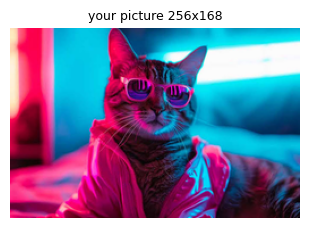

image code: 8fbae0fdc53cfdf2
average colour  R 96.4  G 94.7  B 140.1


In [17]:
SOURCE = "upload"        # "camera" | "upload" | "synth"

def to_working(arr, max_side=256):
    a = np.asarray(arr)[:, :, :3]
    h, w = a.shape[:2]; sc = max_side/max(h, w)
    if sc < 1:
        a = np.array(Image.fromarray(a.astype(np.uint8)).resize(
            (max(8, int(round(w*sc))), max(8, int(round(h*sc)))), Image.LANCZOS))
    h, w = a.shape[:2]
    return np.ascontiguousarray(a[:h-h % 8, :w-w % 8].astype(np.uint8))

def synth_photo(size=192):
    yy, xx = np.mgrid[0:size, 0:size]
    out = np.zeros((size, size, 3), np.uint8)
    out[...] = (40, 45, 60)
    for (cy, cx, rad, col) in [(60, 60, 42, (220, 40, 50)), (120, 130, 38, (40, 170, 90)),
                               (150, 55, 30, (240, 190, 40))]:
        out[((yy-cy)**2 + (xx-cx)**2) < rad**2] = col
    return out

def grab_photo():
    from IPython.display import display, Javascript
    from google.colab.output import eval_js
    display(Javascript("""
      async function takePhoto(q){const d=document.createElement('div');
      const c=document.createElement('button');c.textContent='CLICK TO CAPTURE';
      c.style.cssText='font-size:18px;padding:10px 18px;margin:8px;cursor:pointer';
      d.appendChild(c);const v=document.createElement('video');
      v.style.cssText='display:block;max-width:420px';
      const s=await navigator.mediaDevices.getUserMedia({video:true});
      document.body.appendChild(d);d.appendChild(v);v.srcObject=s;await v.play();
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight,true);
      await new Promise(r=>c.onclick=r);const k=document.createElement('canvas');
      k.width=v.videoWidth;k.height=v.videoHeight;k.getContext('2d').drawImage(v,0,0);
      s.getVideoTracks()[0].stop();d.remove();return k.toDataURL('image/jpeg',q);}"""))
    d = eval_js("takePhoto(0.9)")
    return np.array(Image.open(io.BytesIO(base64.b64decode(d.split(',')[1]))).convert("RGB"))

def load_image(source):
    if source == "camera":
        return grab_photo()
    if source == "upload":
        from google.colab import files
        up = files.upload()
        return np.array(Image.open(io.BytesIO(next(iter(up.values())))).convert("RGB"))
    return synth_photo()

img = to_working(load_image(SOURCE))
show((img, f"your picture {img.shape[1]}x{img.shape[0]}"))
print("image code:", hashlib.sha256(img.tobytes()).hexdigest()[:16])
print("average colour  R %.1f  G %.1f  B %.1f" % tuple(img.reshape(-1, 3).mean(0)))

## A3 · Which channel survives a change of light — 2 marks

The next cell puts your photograph under different light. The scene has not moved. Nothing
about the objects has changed. Only the light.

Then it measures how far every channel moved, in three different colour spaces, as a
percentage of that channel's full range. A channel with a small number barely noticed that
the light changed. A channel with a large number is mostly reporting the light rather than
the objects.

Fill in `STABLE` with the channel that moved least across all nine, and the three numbers
that show it.

Marks: **1** for naming the steadiest channel correctly, **1** more if the numbers you
report match what the measurement actually produced.

This is the fact the rest of the lab is built on, so be sure you believe it before moving
on. It is also the answer to a question worth asking yourself: if you were writing a program
to find a red ball in a photograph, which channel would you look at, and why not the red one?

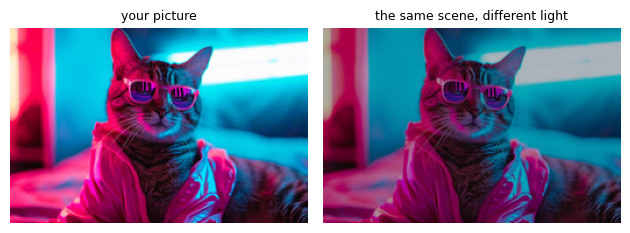

the two pictures agree to 16.88 dB

  RGB    R   3.1%   G   3.5%   B   9.8%
  HSV    H   1.2%   S   2.2%   V  18.0%
  YCrCb  Y   7.8%   Cr   6.4%   Cb   2.2%


In [18]:
# your change of light, from your seed
_r2 = np.random.default_rng(int("{}".format(_h[16:24]), 16))
_warm = _r2.random() < .5
_strength = .03 + .05*_r2.random()
LIGHT_GAIN  = .68 + .14*_r2.random() if _r2.random() < .5 else 1.16 + .22*_r2.random()
LIGHT_GAMMA = .80 + .12*_r2.random() if _r2.random() < .5 else 1.10 + .18*_r2.random()
LIGHT_CAST  = (1+_strength, 1.0, 1-_strength) if _warm else (1-_strength, 1.0, 1+_strength)

relit = relight(img, LIGHT_GAIN, LIGHT_GAMMA, LIGHT_CAST)
show((img, "your picture"), (relit, "the same scene, different light"))
print(f"the two pictures agree to {psnr(img, relit):.2f} dB\n")

for space in ("RGB", "HSV", "YCrCb"):
    s = channel_shift(img, relit, space)
    print(f"  {space:6s} " + "   ".join(f"{k} {v:5.1f}%" for k, v in s.items()))

In [20]:
STABLE = {
    "channel": "H",     # "R","G","B","H","S","V","Y","Cr" or "Cb"
    "it_moved": 1.2,    # that channel's percentage, from the table above
    "worst_channel": "V",   # the channel that moved MOST
    "it_moved_too": 18.0,    # and its percentage
}
assert all(v is not None for v in STABLE.values()), "Fill in all four."
print(json.dumps(STABLE, indent=1, default=float))

{
 "channel": "H",
 "it_moved": 1.2,
 "worst_channel": "V",
 "it_moved_too": 18.0
}


---

# Part B · Work out what the light did, and undo it — 4 marks

The change of light did three things to your picture, in this order:

1. **A curve.** Every value was raised to a power. Below 1 this lifts the shadows; above 1
   it deepens them.
2. **A brightness change.** Everything multiplied by one number. Above 1 is brighter,
   below 1 is darker.
3. **A colour cast.** Red and blue scaled in opposite directions, green left alone. A warm
   light pushes red up and blue down; a cool light does the reverse.

`correct(picture, gain, gamma, cast)` reverses all three. Your job is to find the settings.

## B1 · What happened — 2 marks

Before tuning anything, say what the light did, from the measurements you already have. Was
the picture made brighter or darker? Was the light warm or cool? And roughly how much
brighter or darker?

- **1 mark** for getting brighter-or-darker and warm-or-cool both right.
- **1 mark** for a brightness estimate within 0.12 of the truth.

The average colour of your picture is printed above and the average of the relit one is
printed below. That comparison answers all three questions, and it is a better guide than
your eye, which is already correcting for the light without asking you.

In [21]:
print("your picture  R %6.1f  G %6.1f  B %6.1f" % tuple(img.reshape(-1, 3).mean(0)))
print("relit         R %6.1f  G %6.1f  B %6.1f" % tuple(relit.reshape(-1, 3).mean(0)))
print("\nratio relit / yours:  R %.3f  G %.3f  B %.3f"
      % tuple(relit.reshape(-1, 3).mean(0)/np.maximum(img.reshape(-1, 3).mean(0), 1e-9)))

your picture  R   96.4  G   94.7  B  140.1
relit         R   70.9  G   74.2  B  112.4

ratio relit / yours:  R 0.735  G 0.783  B 0.802


In [23]:
ESTIMATE = {
    "brighter_or_darker": "darker",   # "brighter" or "darker"
    "warm_or_cool":       "cool",   # "warm" (red up, blue down) or "cool" (the reverse)
    "gain":               0.783,   # your number for how much brighter or darker, e.g. 1.25
    "because":            "G is untouched by the colour cast, and its average fell to 78.3% of the original (94.7 to 74.2), so the light got dimmer; R fell further (73.5%) and B fell less (80.2%) than G, meaning red was pushed down and blue pushed up relative to the gain - the signature of a cool light.",   # one sentence: which numbers told you
}
assert all(v is not None for v in ESTIMATE.values()), "Fill in all four."
print(json.dumps(ESTIMATE, indent=1, default=float))

{
 "brighter_or_darker": "darker",
 "warm_or_cool": "cool",
 "gain": 0.783,
 "because": "G is untouched by the colour cast, and its average fell to 78.3% of the original (94.7 to 74.2), so the light got dimmer; R fell further (73.5%) and B fell less (80.2%) than G, meaning red was pushed down and blue pushed up relative to the gain - the signature of a cool light."
}


## B2 · Undo it — 2 marks

Now put the picture back. Tune the three settings until the corrected picture is as close to
your original as you can make it. The score is in dB, and higher is closer.

- **1 mark** for gaining at least **3 dB** over the relit picture.
- **1 mark** for gaining at least **6 dB**.

Two things worth knowing before you start.

**Try the obvious trick first, and watch it fail.** `grey_world(relit)` assumes the average
of the whole picture ought to be neutral grey, and scales each channel to make it so. It is
the first thing anyone reaches for. Run it. On this task it usually scores *worse* than doing
nothing at all, because your photograph is not, on average, grey — and a method that assumes
it is will drag every colour in the picture towards whatever your subject happens to be.

**Change one setting at a time.** `cast` fixes the colour, `gain` fixes the brightness,
`gamma` fixes the contrast in the shadows. If you change all three at once you cannot tell
which one helped.

In [24]:
print("what grey_world suggests for the cast:", tuple(round(c, 3) for c in grey_world(relit)))
_gw = correct(relit, 1.0, 1.0, grey_world(relit))
print(f"  doing nothing at all : {psnr(img, relit):6.2f} dB")
print(f"  grey_world's answer  : {psnr(img, _gw):6.2f} dB")

what grey_world suggests for the cast: (0.826, 0.864, 1.31)
  doing nothing at all :  16.88 dB
  grey_world's answer  :  15.85 dB


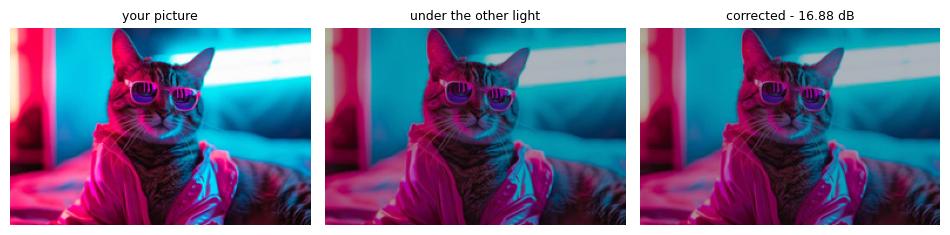

  before  16.88 dB      after  16.88 dB      gained +0.00 dB
  3 dB not yet      6 dB not yet


In [25]:
CORRECTION = {
    "gain":  1.0,
    "gamma": 1.0,
    "cast":  (1.0, 1.0, 1.0),
}

fixed = correct(relit, CORRECTION["gain"], CORRECTION["gamma"], CORRECTION["cast"])
B_BEFORE, B_AFTER = psnr(img, relit), psnr(img, fixed)
B_GAINED = B_AFTER - B_BEFORE
show((img, "your picture"), (relit, "under the other light"), (fixed, f"corrected - {B_AFTER:.2f} dB"))
print(f"  before {B_BEFORE:6.2f} dB      after {B_AFTER:6.2f} dB      gained {B_GAINED:+.2f} dB")
print(f"  {'3 dB reached' if B_GAINED >= 3 else '3 dB not yet'}"
      f"      {'6 dB reached' if B_GAINED >= 6 else '6 dB not yet'}")

---

# Part C · The right format for each picture — 2 marks, and a leaderboard

Three pictures, each a different kind of thing: **your photograph**, a **screenshot** of
text and lines, and a **flat graphic** of solid colour shapes.

Choose the file format and setting for **each one separately** to make the total as small as
possible, while every one of the three still reaches **32 dB** when it is read back.

The formats available are `"PNG"` (lossless, no quality setting), `"JPEG"` (lossy, quality
1 to 95) and `"WEBP"` (either, quality 1 to 100).

You start from plain JPEG at quality 60 for all three. Beat the total.

**One format is not the right answer for all three.** Think about what each picture is made
of: a photograph is smooth and detailed everywhere, a screenshot is flat areas and hard
edges, a flat graphic is a handful of solid colours. PNG predicts each pixel from its
neighbour and stores the difference. JPEG cuts the picture into 8×8 squares and describes
each as a blend of smooth patterns.

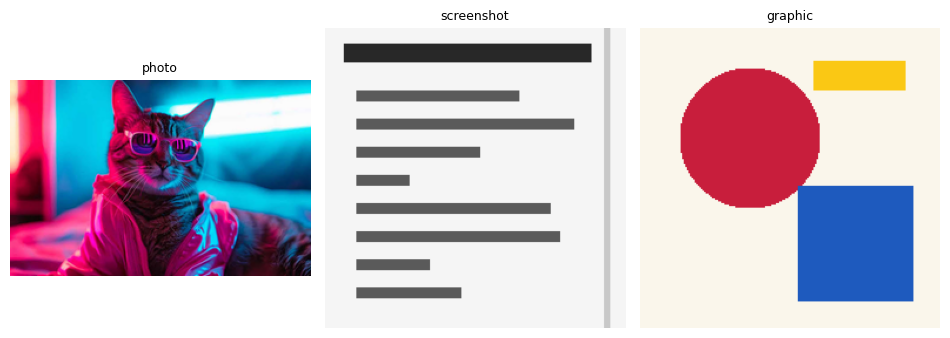

the starting point, plain JPEG quality 60 for all three: 14170 bytes


In [26]:
def make_screenshot(size=192):
    a = np.full((size, size, 3), 245, np.uint8)
    a[10:22, 12:170] = 40
    for r in range(40, 180, 18):
        a[r:r+7, 20:20+int(140*abs(np.sin(r)))] = 90
    a[:, 178:182] = 200
    return a

def make_graphic(size=192):
    a = np.full((size, size, 3), (250, 246, 235), np.uint8)
    yy, xx = np.mgrid[0:size, 0:size]
    a[((yy-70)**2 + (xx-70)**2) < 45**2] = (200, 30, 60)
    a[(xx > 100) & (xx < 175) & (yy > 100) & (yy < 175)] = (30, 90, 190)
    a[(yy > 20) & (yy < 40) & (xx > 110) & (xx < 170)] = (250, 200, 20)
    return a

PICTURES = {"photo": img, "screenshot": to_working(make_screenshot()),
            "graphic": to_working(make_graphic())}
show(*[(v, k) for k, v in PICTURES.items()])
BASE_BYTES = sum(len(encode(v, "JPEG", quality=60)) for v in PICTURES.values())
print(f"the starting point, plain JPEG quality 60 for all three: {BASE_BYTES} bytes")

In [52]:
CHOICES = {
    "photo":      {"format": "WEBP", "quality": 70},
    "screenshot": {"format": "JPEG", "quality": 22},
    "graphic":    {"format": "JPEG", "quality": 71},
}

def _pack(im, c):
    f = c["format"].upper()
    if f == "PNG":
        return encode(im, "PNG", optimize=True)
    if f == "JPEG":
        return encode(im, "JPEG", quality=int(c.get("quality", 60)))
    if f == "WEBP":
        return encode(im, "WEBP", quality=int(c.get("quality", 60)), method=6)
    raise ValueError(f"unknown format {c['format']!r}")

C_TOTAL, C_OK, C_ROWS = 0, True, []
for name, im in PICTURES.items():
    blob = _pack(im, CHOICES[name]); q = psnr(im, decode(blob))
    C_TOTAL += len(blob); C_OK &= q >= 32.0
    C_ROWS.append((name, CHOICES[name]["format"].upper(),
                   CHOICES[name].get("quality", "-"), len(blob), q))
    print(f"  {name:11s} {CHOICES[name]['format'].upper():5s} "
          f"q={str(CHOICES[name].get('quality','-')):>3s}  {len(blob):7d} bytes   "
          f"{q:6.2f} dB  {'ok' if q >= 32 else 'UNDER 32 dB - does not count'}")
C_BASE = BASE_BYTES
print(f"\n  your total {C_TOTAL} bytes   starting point {C_BASE} bytes   "
      f"{'VALID' if C_OK else 'INVALID - one picture is under 32 dB'}")
print(f"  {'beats the starting point' if (C_OK and C_TOTAL < C_BASE*0.95) else 'not enough of an improvement yet'}")

  photo       WEBP  q= 70     5720 bytes    28.77 dB  UNDER 32 dB - does not count
  screenshot  JPEG  q= 22     3402 bytes    32.53 dB  ok
  graphic     JPEG  q= 71     3195 bytes    32.16 dB  ok

  your total 12317 bytes   starting point 14170 bytes   INVALID - one picture is under 32 dB
  not enough of an improvement yet


---

# Part D · Say what you found

Three or four sentences each, about **your own numbers**. These are read and marked.

In [28]:
EXPLAIN = {
    "which_channel_survived": None,
        # Part A: which channel barely moved when the light changed, which moved most,
        # and why that is what you would expect from what each channel measures.

    "how_you_undid_it": None,
        # Part B: what did you change first, what did each setting do to the score, and
        # what happened when you tried grey_world?

    "format_choices": None,
        # Part C: why a different format for a photograph than for a screenshot?
}
assert all(v and len(str(v).strip()) > 40 for v in EXPLAIN.values()), "All three, properly."
for k, v in EXPLAIN.items(): print(f"{k}:\n  {v}\n")

AssertionError: All three, properly.

In [ ]:
def _b64png(a):
    return base64.b64encode(encode(a, "PNG", optimize=True)).decode()

ANSWERS = {
    "lab": "lab03", "version": 1, "bits_id": BITS_ID.strip().upper(), "seed": SEED,
    "generated": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "A": {k: (str(v) if k == "changed_most" else float(v)) for k, v in A.items()},
    "A2_ok": bool(A2_ok),
    "stable": STABLE,
    "light": {"gain": float(LIGHT_GAIN), "gamma": float(LIGHT_GAMMA),
              "cast": [float(c) for c in LIGHT_CAST]},
    "estimate": ESTIMATE,
    "correction": {"gain": float(CORRECTION["gain"]), "gamma": float(CORRECTION["gamma"]),
                   "cast": [float(c) for c in CORRECTION["cast"]],
                   "before": float(B_BEFORE), "after": float(B_AFTER),
                   "gained": float(B_GAINED)},
    "C": {"choices": CHOICES, "total": int(C_TOTAL), "baseline": int(C_BASE),
          "valid": bool(C_OK),
          "rows": [[r[0], r[1], str(r[2]), int(r[3]), float(r[4])] for r in C_ROWS]},
    "EXPLAIN": EXPLAIN,
    "images": {"main": _b64png(img)},
}
print("===== LAB03 ANSWER BLOCK v1 =====")
print(json.dumps(ANSWERS, separators=(",", ":"), default=float))
print("===== END LAB03 ANSWER BLOCK =====")
print("\npackaged. Now save to GitHub.")

### Handing it in

1. **Run every cell from top to bottom, and run the cell above this one last.**
2. **File → Download → Download .ipynb**
3. **Rename the file to exactly `lab03.ipynb`.** Colab usually calls it
   `Copy of lab03.ipynb`, and that name will not be accepted.
4. Open your own repository:
   `github.com/BITS-F459-Computer-Vision/f459-<your BITS ID, lowercase>`
5. **Add file → Upload files**, drag it in, **Commit changes**.
6. **Click the file on GitHub and check you can see your outputs in it.**

> **The outputs are what gets marked.** If you download before running the last cell, the
> file has nothing in it to mark. Uploading again later replaces it, so the last one counts.

### Before you go

- [ ] A1 shows PASS · A2 shows PASS
- [ ] Working table filled in, both pixels, intermediates included
- [ ] `STABLE` filled in
- [ ] `ESTIMATE` filled in **before** you started tuning
- [ ] `CORRECTION` gains at least 3 dB, and 6 dB if you can get it
- [ ] Part C says VALID and beats the starting point
- [ ] All three `EXPLAIN` answers written
- [ ] Answer block run last, its output visible
- [ ] Downloaded, renamed to exactly `lab03.ipynb`, uploaded to your repo
- [ ] You clicked the file on GitHub and saw your outputs